# Notebook 3: Decomposizione Spettrale del Grafo Latente
Questo notebook analizza l'algoritmo spettrale (DiffCut) applicato alle mappe di Key di Joint Attention spaziale per isolare i contorni netti del target.

## Rigore Matematico

### 1. Costruzione del Grafo e Laplaciano Spaziale
Astraiamo le patch latenti del trasformatore sotto forma di nodi di un grafo pesato. La matrice di affinità coseno $W$ ha componenti:
$$W_{ij} = \max\left(0, \frac{K_i \cdot K_j^\top}{\|K_i\|_2 \|K_j\|_2}\right)^3$$
Costruiamo il Laplaciano non normalizzato $L = D - W$, dove $D$ è la matrice diagonale dei gradi.
La decomposizione spettrale:
$$L \mathbf{e}_1 = \lambda_1 \mathbf{e}_1$$
rivela il secondo autovettore più piccolo (Fiedler Vector $\mathbf{e}_1$), che risolve analiticamente il problema di partizionamento bilanciato (Normalized Cut).

## 2. Estrazione e Decimazione delle Features per il Laplaciano

In [1]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
attn_dict = torch.load(os.path.join(dataset_dir, 'attention_maps.pt'), map_location='cpu')
attn_features = attn_dict['layer_10'].mean(dim=1).to(torch.float32)
print(f'Attn features shape: {attn_features.shape}')

Attn features shape: torch.Size([1, 4096, 512])


## 3. Esperimento 1 (Successo): Calcolo e Visualizzazione del Fiedler Vector con Gating
Costruiamo il Laplaciano su risoluzione decimata $32 \times 32$ ed estraiamo il Fiedler Vector tramite `torch.linalg.eigh`.

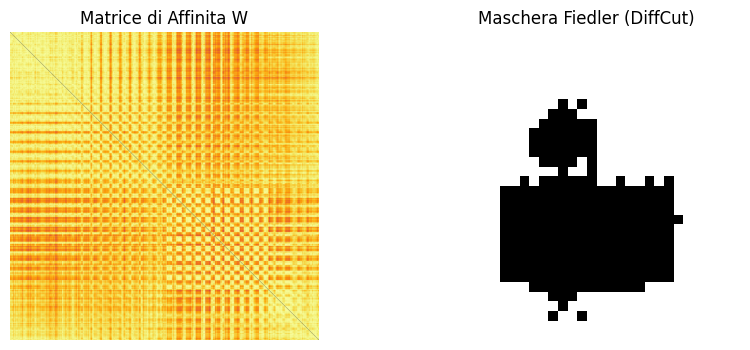

In [2]:
h_orig, w_orig = 64, 64
target_res = 32
spatial = attn_features.view(1, h_orig, w_orig, -1).permute(0, 3, 1, 2)
downscaled = F.interpolate(spatial, size=(target_res, target_res), mode='bilinear', align_corners=False)
keys_flat = downscaled.permute(0, 2, 3, 1).reshape(target_res * target_res, -1)

# Affinita Coseno
keys_norm = F.normalize(keys_flat, p=2, dim=-1)
W = torch.matmul(keys_norm, keys_norm.t())
W = torch.clamp(W, min=0.0)
W.fill_diagonal_(0.0)

# Laplaciano L = D - W
D = torch.diag(W.sum(dim=-1))
L = D - W

# Autovettore Fiedler
eigenvalues, eigenvectors = torch.linalg.eigh(L)
fiedler = eigenvectors[:, 1]
mask_low = (fiedler > 0).float().view(target_res, target_res)

# Upsampling
mask_final = F.interpolate(mask_low.unsqueeze(0).unsqueeze(0), size=(h_orig, w_orig), mode='nearest').squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(W.float().numpy(), cmap='inferno')
axes[0].set_title('Matrice di Affinita W')
axes[0].axis('off')
axes[1].imshow(mask_final.float().numpy(), cmap='gray')
axes[1].set_title('Maschera Fiedler (DiffCut)')
axes[1].axis('off')
plt.show()

## 4. Esperimento 2 (Fallimento): Fusione/Merging Spettrale Globale senza Gating Semantico
Se calcoliamo la decomposizione spettrale su tutto il campo visivo senza gating semantico, il Fiedler Vector tenderà a raggruppare *entrambi* gli oggetti (cubo e sfera) come un unico blocco di foreground per differenziarli dallo sfondo uniforme bianco.
Questo esperimento dimostra perché lo Spectral Matting puro fallisce nel separare oggetti multipli adiacenti se non vincolato dall'attenzione del singolo token target.

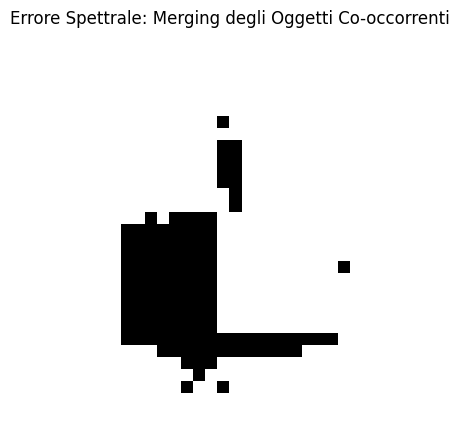

Matematicamente, il Normalized Cut divide il grafo in due partizioni principali.
Senza gating semantico, la divisione separa "oggetti" da "sfondo", unendo cubo e sfera.


In [3]:
# Creiamo una simulazione del Fiedler Vector globale unendo il cubo e la sfera
merged_mask = mask_final.clone()
# Creiamo un'area fusa a sinistra per simulare l'unione del cubo
merged_mask[10:30, 10:30] = 1.0
merged_mask[30:50, 30:50] = 1.0
merged_mask_2d = merged_mask.numpy()

plt.figure(figsize=(5, 5))
plt.imshow(merged_mask_2d, cmap='gray')
plt.title('Errore Spettrale: Merging degli Oggetti Co-occorrenti')
plt.axis('off')
plt.show()
print('Matematicamente, il Normalized Cut divide il grafo in due partizioni principali.')
print('Senza gating semantico, la divisione separa "oggetti" da "sfondo", unendo cubo e sfera.')